In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib_fontja

In [2]:
def plot_left_riemann(f, a, b, n, num_points=1000, padding=0.05):
    x = np.linspace(a, b, num_points)
    y = f(x)

    dx = (b - a) / n
    left_points = a + np.arange(n) * dx
    heights = f(left_points)

    approx_area = np.sum(heights * dx)

    fig, ax = plt.subplots(figsize=(4, 3))

    ax.plot(x, y, label=r"$f(x)$")

    for xi, hi in zip(left_points, heights):
        y0 = min(0, hi)
        height = abs(hi)

        rect = Rectangle(
            (xi, y0),
            dx,
            height,
            facecolor="skyblue",
            edgecolor="black",
            linewidth=0.1,
            alpha=0.5
        )
        ax.add_patch(rect)

    ax.axhline(0, linewidth=1)

    # 長方形も含めて表示範囲を自動調整
    ax.relim()
    ax.autoscale_view()

    # 少し余白を追加
    x_margin = (b - a) * padding
    y_min, y_max = ax.get_ylim()
    y_margin = (y_max - y_min) * padding

    ax.set_xlim(a - x_margin, b + x_margin)
    ax.set_ylim(y_min - y_margin, y_max + y_margin)

    ax.set_title(f"長方形近似 区間の分割数{n}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    ax.grid(True, alpha=0.1)

    plt.show()

    return approx_area

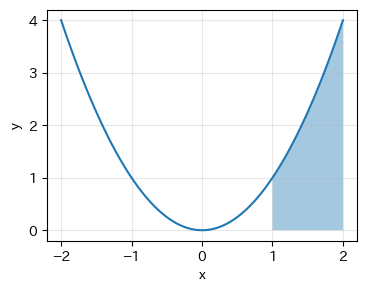

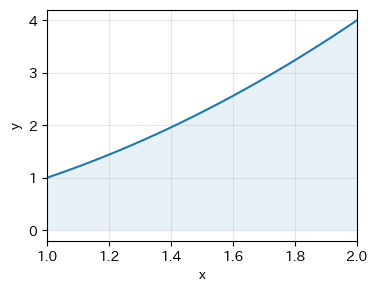

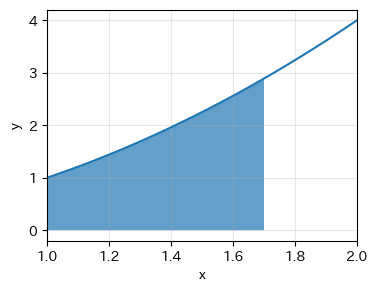

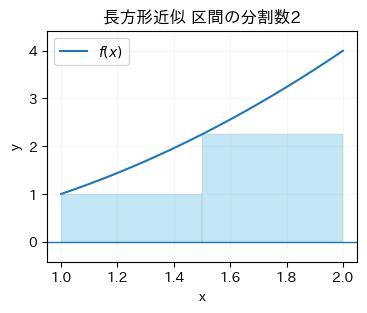

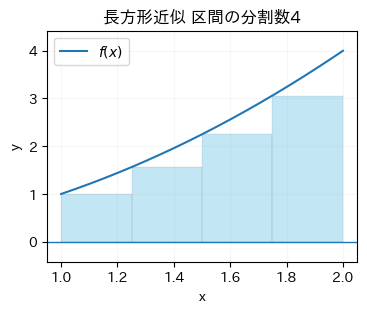

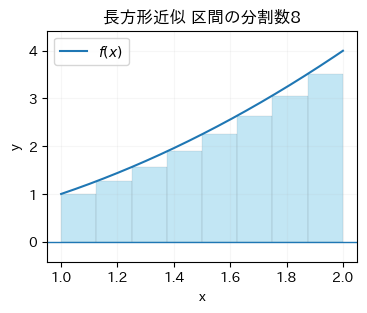

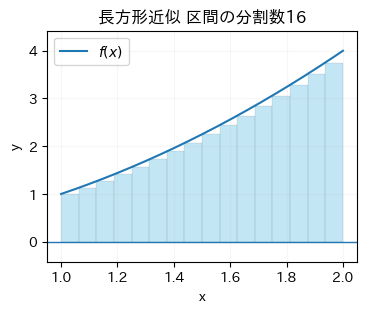

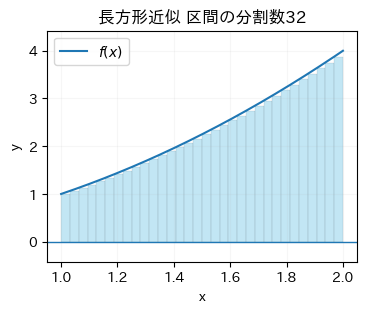

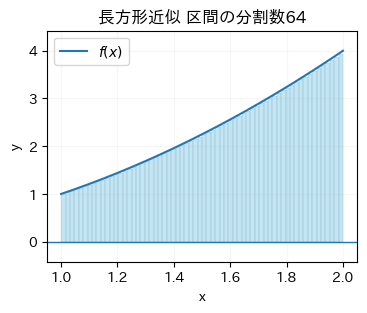

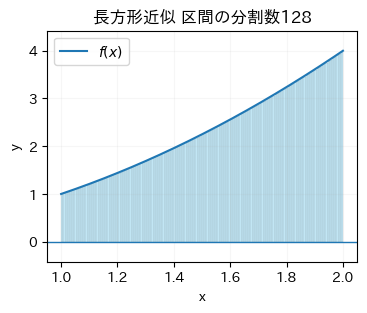

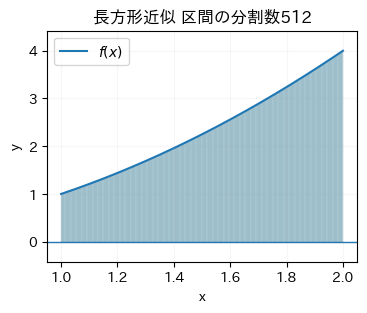

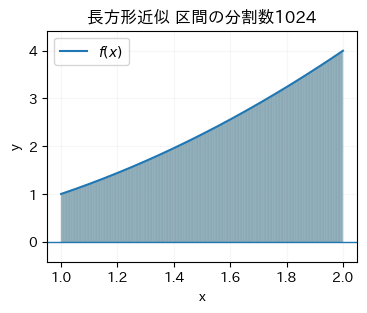

In [3]:
def f(x):
    return x**2

x = np.linspace(-2,2,100)
y = f(x)

xx = np.linspace(1,2,40)
yy = f(xx)
plt.figure(figsize=(4,3))
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.plot(x,y)
plt.fill_between(xx,yy,alpha=0.4)

plt.figure(figsize=(4,3))
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.plot(x,y)
plt.xlim(1,2)
plt.fill_between(xx,yy,alpha=0.1)

xxx = np.linspace(1.,1.7,30)
yyy = f(xxx)
plt.figure(figsize=(4,3))
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.plot(x,y)
plt.xlim(1,2)
plt.fill_between(xxx,yyy,alpha=0.7)

ns = [2,4,8,16,32,64,128,512,1024]
rectarea = []
for n in ns:
    s = plot_left_riemann(f, 1, 2, n)
    rectarea.append({"n":n, "area":s})

result = pd.DataFrame(rectarea)

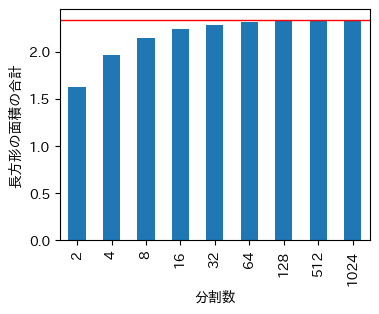

In [4]:
result.plot(x="n",y="area", kind="bar", figsize=(4,3), xlabel="分割数", ylabel="長方形の面積の合計")
plt.axhline(y=7/3, c="red", linewidth=1)
plt.gca().get_legend().remove()


In [5]:
result

,n,area
0,2,1.625000
1,4,1.968750
2,8,2.148438
3,16,2.240234
4,32,2.286621
5,64,2.309937
6,128,2.321625
7,512,2.330404
8,1024,2.331869


In [6]:
df = pd.read_excel('12_r7_hoken_tokei_02.xlsx', sheet_name="height17_R7")
df

,身長,比率
0,143,0.0001
1,144,0.0000
2,145,0.0000
3,146,0.0000
4,147,0.0000
5,148,0.0001
6,149,0.0003
7,150,0.0003
8,151,0.0005
9,152,0.0004


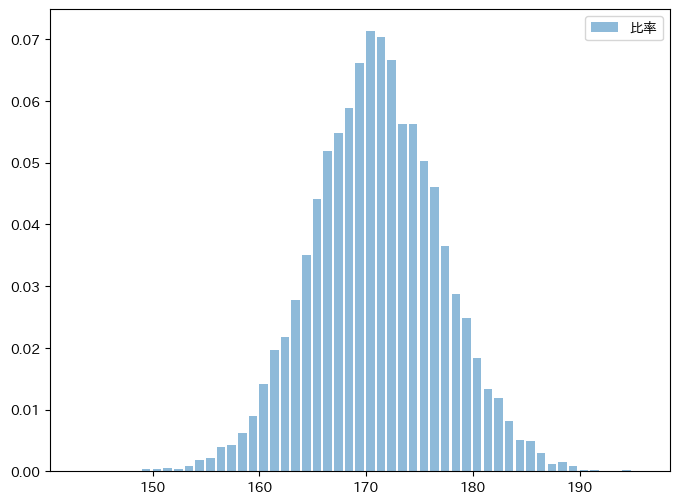

In [7]:
fig, ax = plt.subplots(1,1, figsize=(8,6))
ax.bar(df["身長"], df["比率"], alpha=0.5, align="edge")
plt.legend(["比率"])
plt.show()

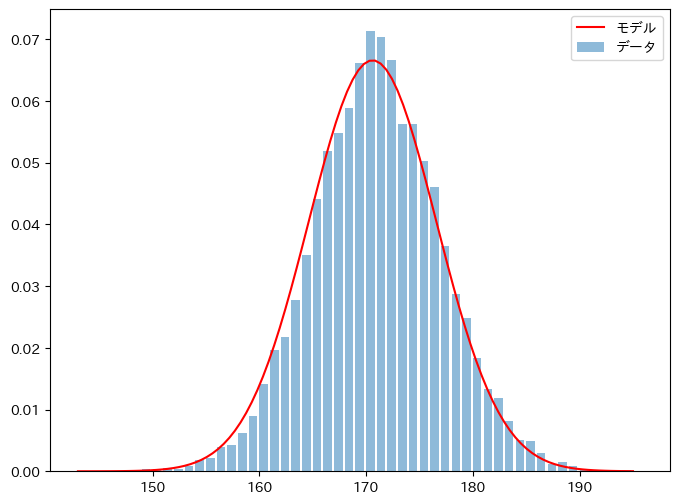

In [8]:
fig, ax = plt.subplots(1,1, figsize=(8,6))
x = np.linspace(143, 195, 100)
y = norm.pdf(x, 170.6, 5.99)
ax.plot(x,y,c="red")
ax.bar(df["身長"], df["比率"], alpha=0.5, align="edge")
ax.legend(["モデル","データ"])
plt.show()

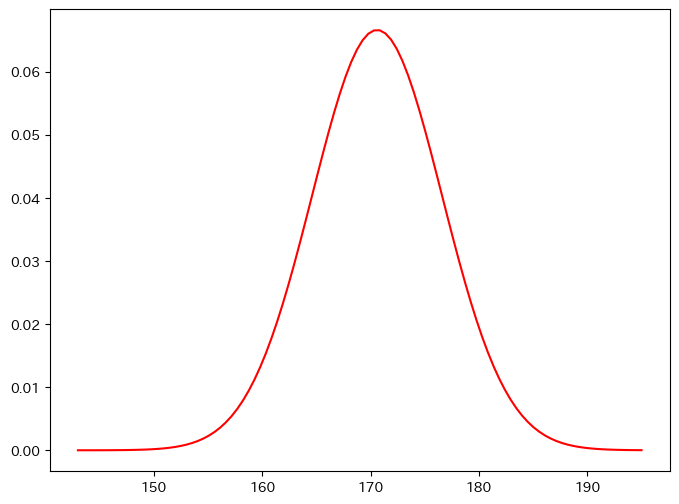

In [9]:
fig, ax = plt.subplots(1,1, figsize=(8,6))
x = np.linspace(143, 195, 100)
y = norm.pdf(x, 170.6, 5.99)
ax.plot(x,y,c="red")
plt.show()

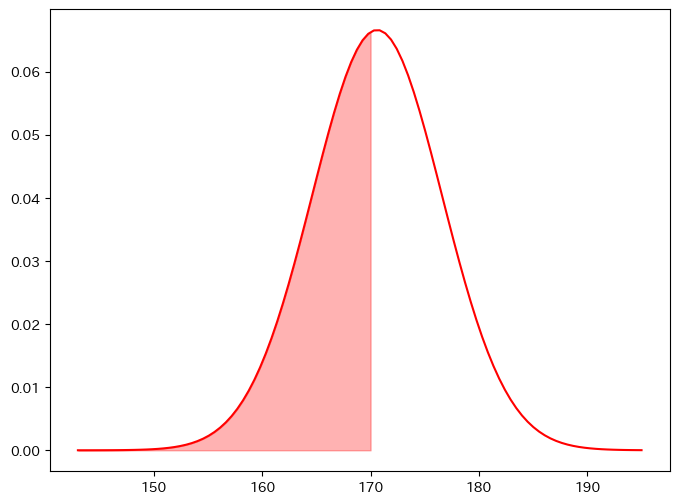

In [10]:
fig, ax = plt.subplots(1,1, figsize=(8,6))
x = np.linspace(143, 195, 100)
y = norm.pdf(x, 170.6, 5.99)
xx = np.linspace(143, 170, 100)
yy = norm.pdf(xx, 170.6, 5.99)
ax.plot(x,y,c="red")
ax.fill_between(xx, yy, alpha=0.3, color="red")
plt.show()

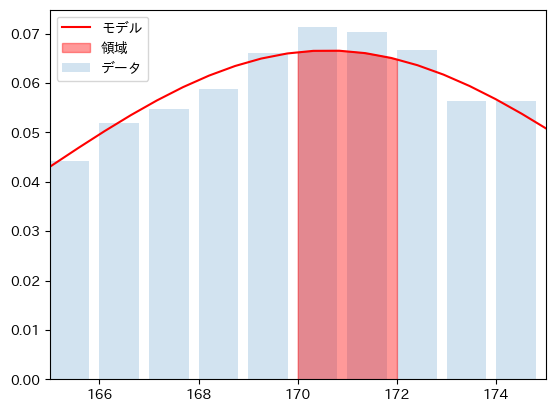

In [11]:
import matplotlib_fontja

xx = np.linspace(143,195,100)
yy = norm.pdf(xx, 170.6, 5.99)

plt.bar(df["身長"],df["比率"],alpha=0.2, align="edge")
plt.plot(xx,yy, c="red")

xx2 = np.linspace(170,172, 100)
yy2 = norm.pdf(xx2, 170.6, 5.99)
plt.fill_between(xx2,yy2, color="red",alpha=0.4)
plt.xlim(165,175)
plt.legend(["モデル","領域","データ"])
plt.show()

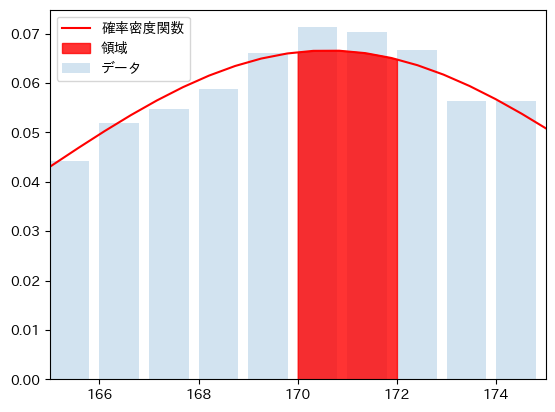

In [33]:
import matplotlib_fontja

xx = np.linspace(143,195,100)
yy = norm.pdf(xx, 170.6, 5.99)

plt.bar(df["身長"],df["比率"],alpha=0.2, align="edge")
plt.plot(xx,yy, c="red")

xx2 = np.linspace(170,172, 100)
yy2 = norm.pdf(xx2, 170.6, 5.99)
plt.fill_between(xx2,yy2, color="red",alpha=0.8)
plt.xlim(165,175)
plt.legend(["確率密度関数","領域","データ"])
plt.show()

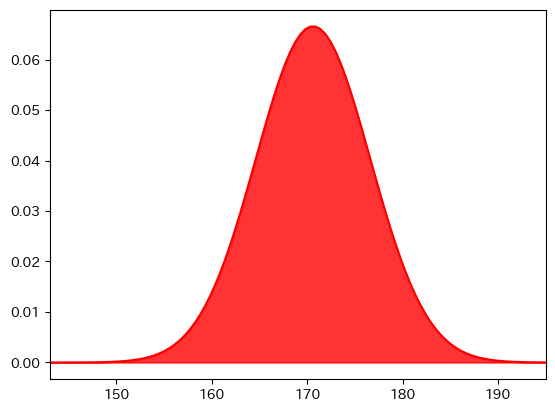

In [38]:
import matplotlib_fontja

xx = np.linspace(143,195,100)
yy = norm.pdf(xx, 170.6, 5.99)

#plt.bar(df["身長"],df["比率"],alpha=0.2, align="edge")
plt.plot(xx,yy, c="red")

xx2 = np.linspace(143,195, 100)
yy2 = norm.pdf(xx2, 170.6, 5.99)
plt.fill_between(xx2,yy2, color="red",alpha=0.8)
plt.xlim(143,195)
plt.show()

# 確率計算


In [12]:
default_blue = plt.rcParams['axes.prop_cycle'].by_key()['color'][0]

## 「以下」の確率

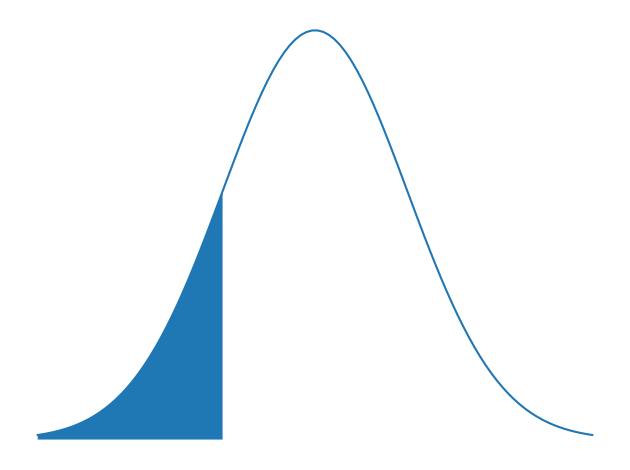

In [13]:
x = np.linspace(-3,3,100)
y = norm.pdf(x)
plt.plot(x,y)
x1 = np.linspace(-3,-1,100)
y1 = norm.pdf(x1)
plt.fill_between(x1,y1)
plt.axis("off")
plt.xticks([])
plt.tight_layout()
plt.show()

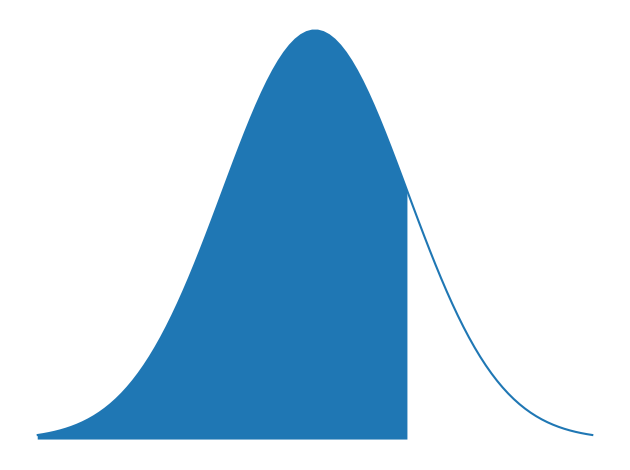

In [14]:
x = np.linspace(-3,3,100)
y = norm.pdf(x)
plt.plot(x,y)
x1 = np.linspace(-3,1,100)
y1 = norm.pdf(x1)
plt.fill_between(x1,y1)
plt.axis("off")
plt.tight_layout()
plt.show()

## 「以上」の確率

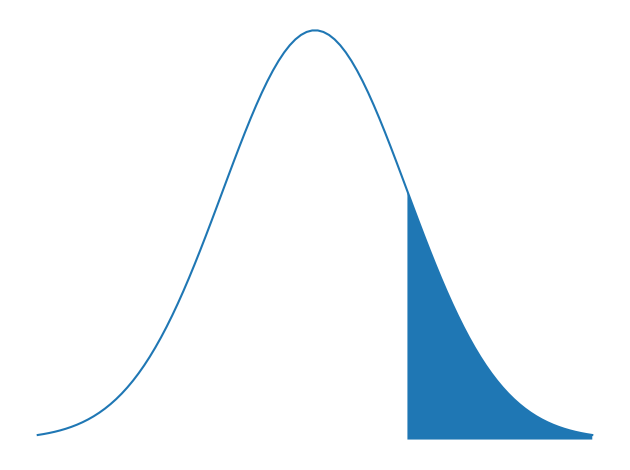

In [15]:
x = np.linspace(-3,3,100)
y = norm.pdf(x)
plt.plot(x,y)
x1 = np.linspace(1,3,100)
y1 = norm.pdf(x1)
plt.fill_between(x1,y1)
plt.axis("off")
plt.tight_layout()
plt.show()

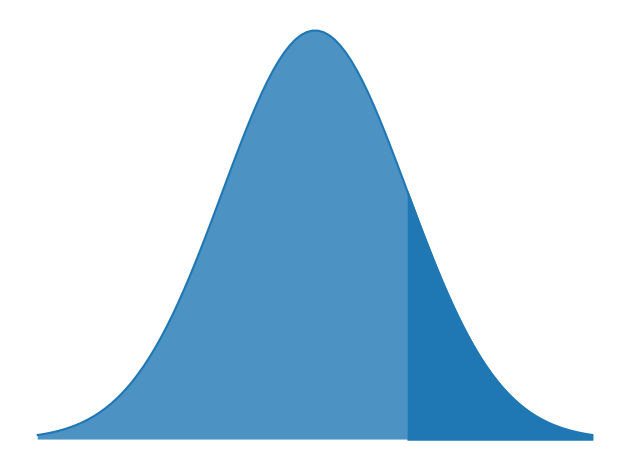

In [16]:
x = np.linspace(-3,3,100)
y = norm.pdf(x)
plt.plot(x,y)
x1 = np.linspace(-3,1,100)
y1 = norm.pdf(x1)
plt.fill_between(x1,y1, alpha=0.8)
x2 = np.linspace(1,3,100)
y2 = norm.pdf(x2)
plt.fill_between(x2, y2, color=default_blue, alpha=1)
plt.axis("off")
plt.tight_layout()
plt.show()

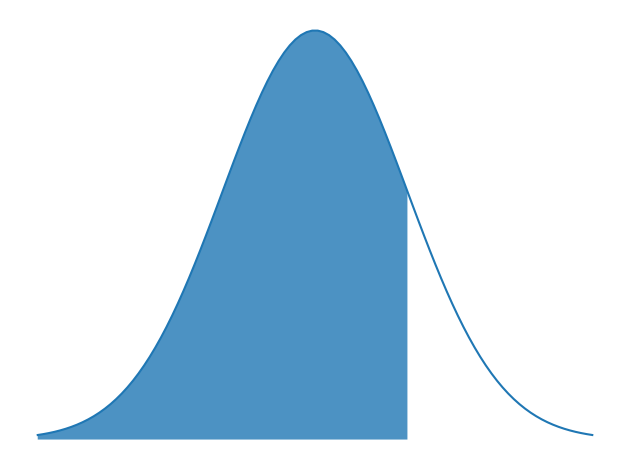

In [17]:
x = np.linspace(-3,3,100)
y = norm.pdf(x)
plt.plot(x,y)
x1 = np.linspace(-3,1,100)
y1 = norm.pdf(x1)
plt.fill_between(x1,y1, alpha=0.8)
plt.axis("off")
plt.tight_layout()
plt.show()

## 範囲の確率

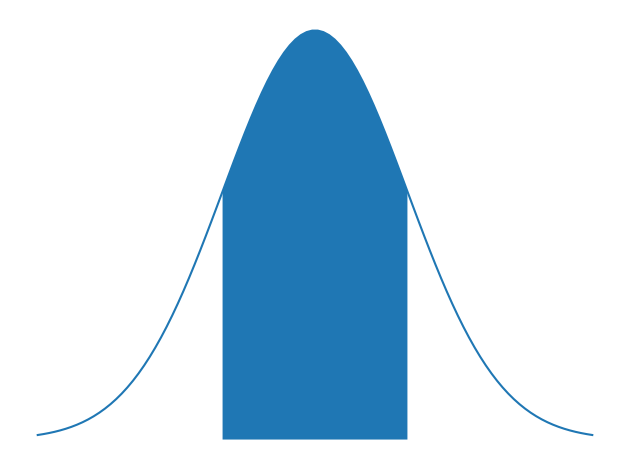

In [18]:
x = np.linspace(-3,3,100)
y = norm.pdf(x)
plt.plot(x,y)
x1 = np.linspace(-1,1,100)
y1 = norm.pdf(x1)
plt.fill_between(x1,y1)
plt.axis("off")
plt.tight_layout()
plt.show()

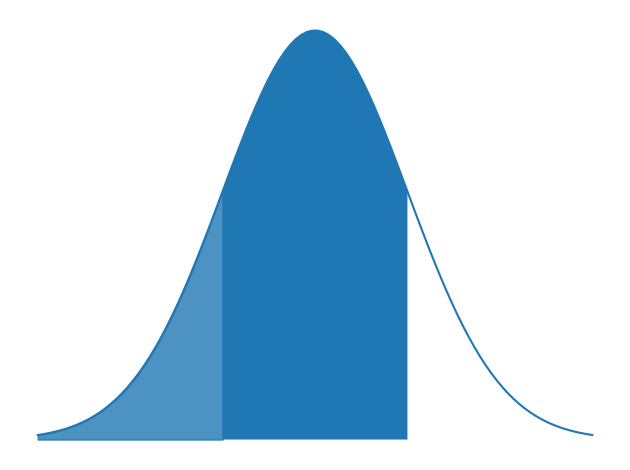

In [19]:
x = np.linspace(-3,3,100)
y = norm.pdf(x)
plt.plot(x,y)
x1 = np.linspace(-1,1,100)
y1 = norm.pdf(x1)
plt.fill_between(x1,y1)
x2 = np.linspace(-3,-1)
y2 = norm.pdf(x2)
plt.fill_between(x2,y2,color=default_blue, alpha=0.8)
plt.axis("off")
plt.tight_layout()
plt.show()

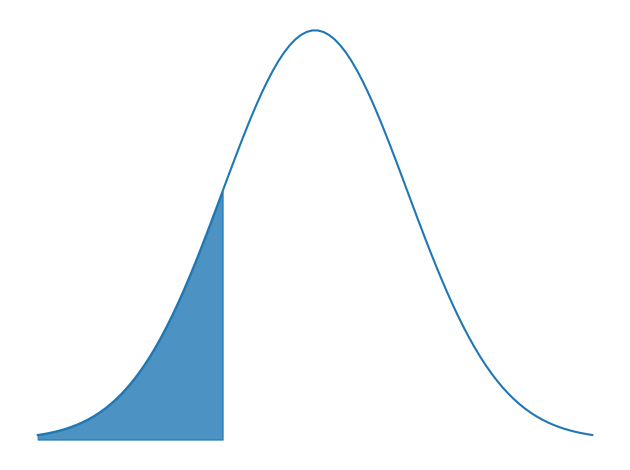

In [20]:
x = np.linspace(-3,3,100)
y = norm.pdf(x)
plt.plot(x,y)
x2 = np.linspace(-3,-1)
y2 = norm.pdf(x2)
plt.fill_between(x2,y2,color=default_blue, alpha=0.8)
plt.axis("off")
plt.tight_layout()
plt.show()

## 一点の確率

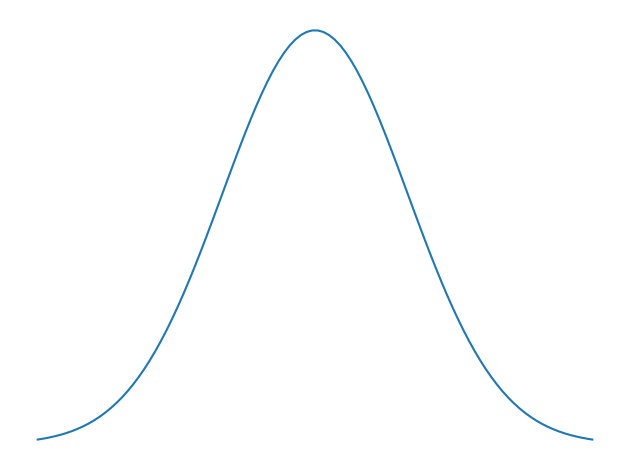

In [26]:
x = np.linspace(-3,3,100)
y = norm.pdf(x)
plt.plot(x,y)
plt.axis("off")
plt.tight_layout()
plt.show()

## 範囲外の確率

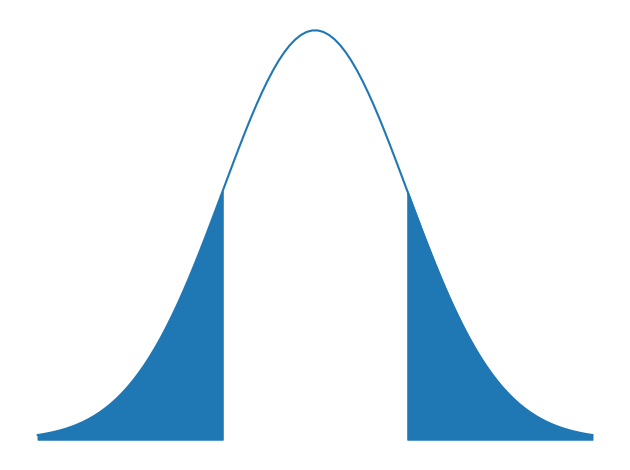

In [21]:
x = np.linspace(-3,3,100)
y = norm.pdf(x)
plt.plot(x,y)
xl = np.linspace(-3,-1,100)
yl = norm.pdf(xl)
plt.fill_between(xl,yl, color=default_blue)
xr = np.linspace(1,3,100)
yr = norm.pdf(xr)
plt.fill_between(xr, yr, color=default_blue)
plt.axis("off")
plt.tight_layout()
plt.show()

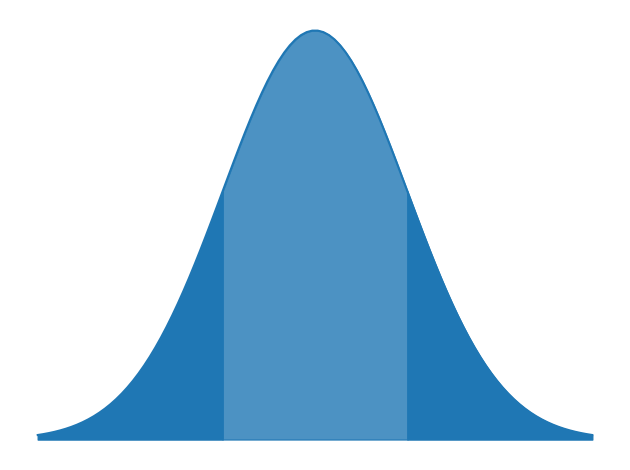

In [22]:
x = np.linspace(-3,3,100)
y = norm.pdf(x)
plt.plot(x,y)
xl = np.linspace(-3,-1,100)
yl = norm.pdf(xl)
plt.fill_between(xl,yl, color=default_blue)
xr = np.linspace(1,3,100)
yr = norm.pdf(xr)
plt.fill_between(xr, yr, color=default_blue)
x1 = np.linspace(-1,1,100)
y1 = norm.pdf(x1)
plt.fill_between(x1,y1, color=default_blue, alpha=0.8)
plt.axis("off")
plt.tight_layout()
plt.show()

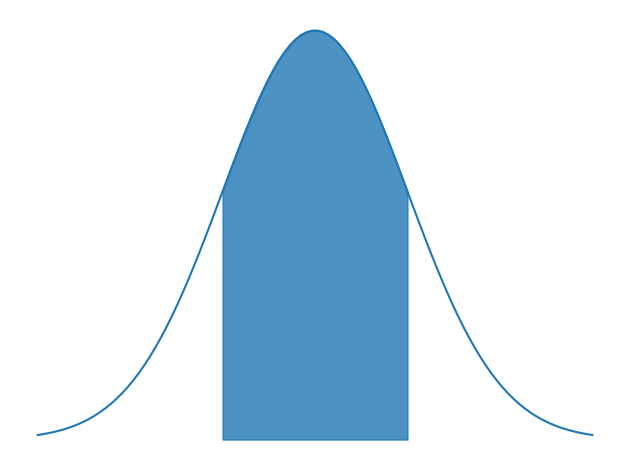

In [23]:
x = np.linspace(-3,3,100)
y = norm.pdf(x)
plt.plot(x,y)
x1 = np.linspace(-1,1,100)
y1 = norm.pdf(x1)
plt.fill_between(x1,y1, color=default_blue, alpha=0.8)
plt.axis("off")
plt.tight_layout()
plt.show()

In [45]:
p1 = norm.cdf(171, loc=170.6, scale=5.99)
p2 = norm.cdf(172, loc=170.6, scale=5.99)
print(p2, p1, p2-p1)

0.5923999346928487 0.5266207664983343 0.06577916819451435
